# Worksheet-1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Introduction to Python Imaging Library(PIL)
## 2.1 Exercise- 1:
Complete all the Task.
### 1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image

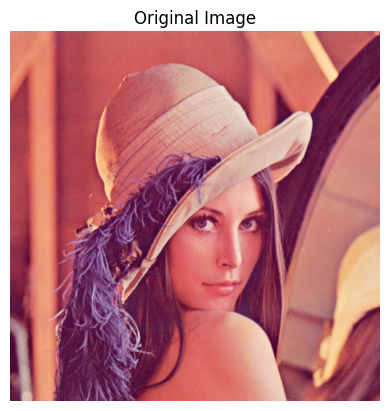

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = Image.open("lena.png")

# Display image
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

### 2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing

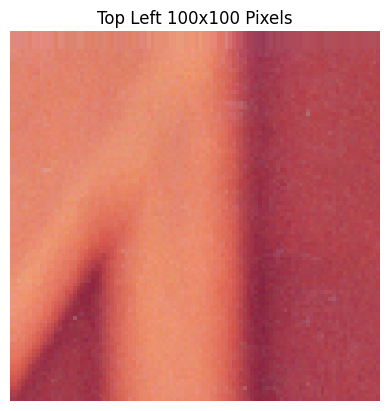

In [ ]:
# Convert image to numpy array
img_array = np.array(img)

# Extract top-left 100x100 pixels
top_left = img_array[0:100, 0:100]

# Display
plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

### 3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

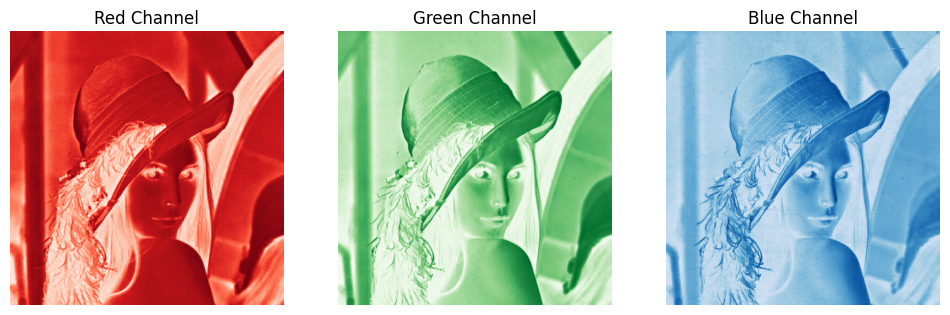

In [ ]:
# Extract color channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

# Display channels
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

### 4. Modify the top 100 ×100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

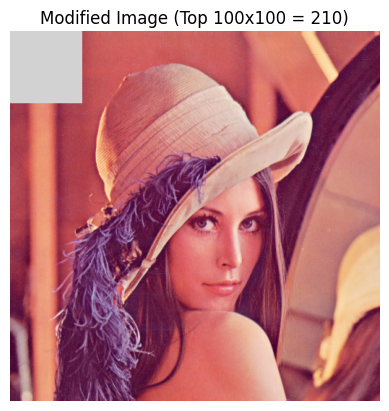

In [ ]:
# Copy image array
modified_img = img_array.copy()

# Change top-left 100x100 pixels to 210
modified_img[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

# 2.2 Exercise- 2

## 1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

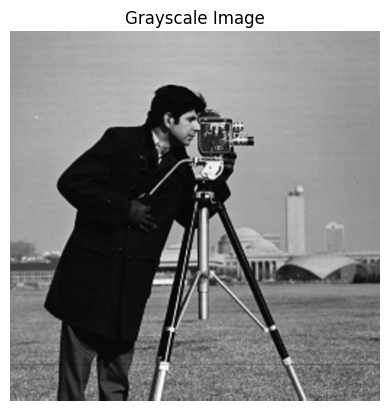

In [ ]:
# Load image and convert to grayscale
img = Image.open("cameraman.png").convert("L")

# Convert to numpy array
img_array = np.array(img)

# Display
plt.imshow(img_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

## 2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib

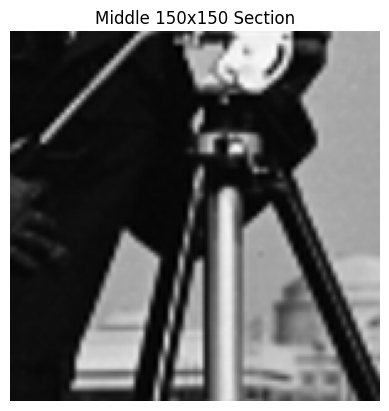

In [ ]:
# Get image dimensions
h, w = img_array.shape

# Find center
center_h = h // 2
center_w = w // 2

# Crop 150x150 section from center
middle = img_array[center_h-75:center_h+75, center_w-75:center_w+75]

# Display
plt.imshow(middle, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

## 3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.

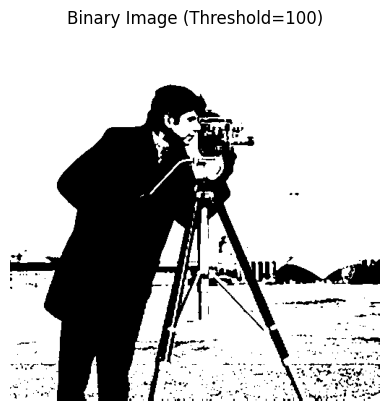

In [ ]:
# Create binary image
binary_img = img_array.copy()

binary_img[binary_img < 100] = 0
binary_img[binary_img >= 100] = 255

# Display
plt.imshow(binary_img, cmap="gray")
plt.title("Binary Image (Threshold=100)")
plt.axis("off")
plt.show()

## 4. Rotate the image 90 degrees clockwise and display the result.
• Rotatethe image by90degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib

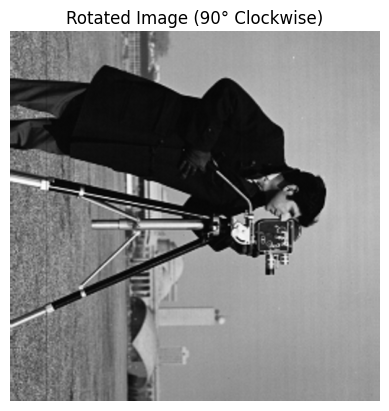

In [ ]:
# Rotate image
rotated = img.rotate(-90, expand=True)

# Display
plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image (90° Clockwise)")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

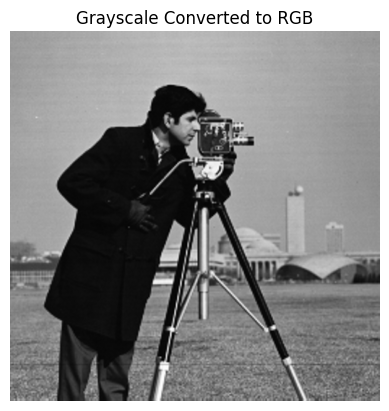

In [ ]:
# Stack grayscale channel into 3 channels
rgb_img = np.stack((img_array,)*3, axis=-1)

# Display
plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

# 3 Image Compression and Decompression using PCA

## 1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset- Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.

Load Image and Convert to Grayscale

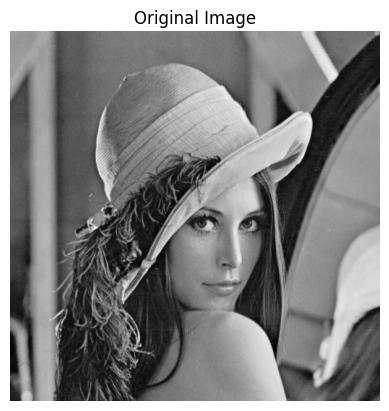

In [ ]:
img = Image.open("lena.png").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

Standardize (Center) the Data

In [ ]:
# Convert to float
X = img_array.astype(float)

# Compute mean
mean = np.mean(X, axis=0)

# Center the data
X_centered = X - mean

Compute Covariance Matrix

In [ ]:
cov_matrix = np.cov(X_centered, rowvar=False)
print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (512, 512)


## 2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot

In [ ]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

Sort Eigenvalues in Descending Order

In [ ]:
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [ ]:
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

Plot Cumulative Explained Variance

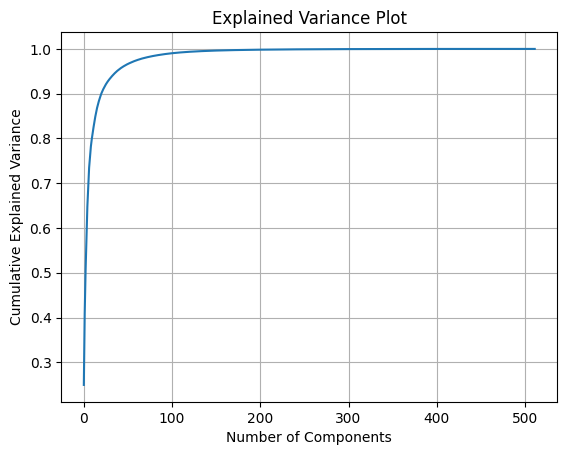

In [ ]:
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid()
plt.show()

# 3. Reconstruction and Experiment

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec
tors(PCs) to obtain a lower-dimensional representation

In [ ]:
def pca_reconstruct(X_centered, eigenvectors, k, mean):

    # Select top k eigenvectors
    V = eigenvectors[:, :k]

    # Project data
    compressed = np.dot(X_centered, V)

    # Reconstruct
    reconstructed = np.dot(compressed, V.T) + mean

    return reconstructed

• Experiments: Pick Four different combination of principal components with various ex
plained variance value and compare the result

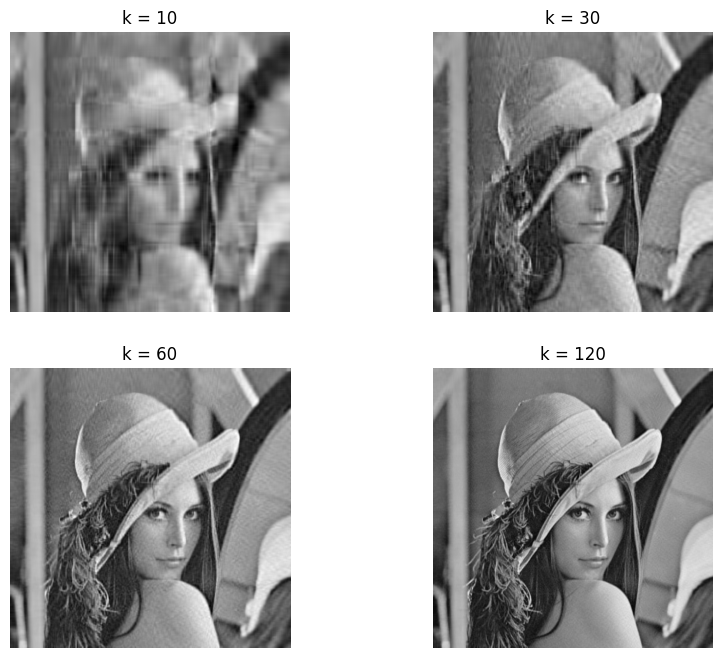

In [ ]:
k_values = [10, 30, 60, 120]

plt.figure(figsize=(10,8))

for i,k in enumerate(k_values):

    reconstructed = pca_reconstruct(X_centered, sorted_eigenvectors, k, mean)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()

Display Original vs Reconstructed

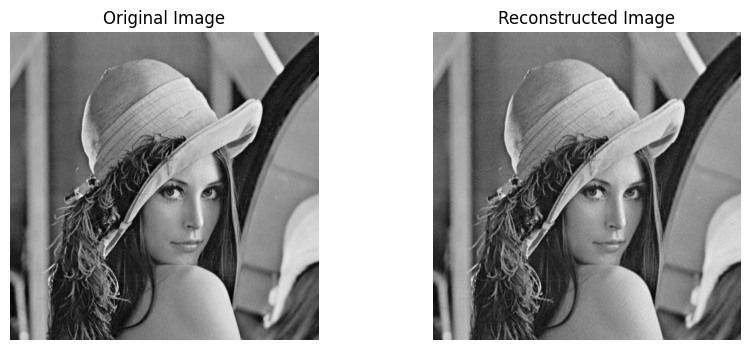

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.show()